In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [7]:
movie_data = pd.read_csv("IMDB Movies India.csv.zip",encoding="latin1")
movie_data

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali
...,...,...,...,...,...,...,...,...,...,...
15504,Zulm Ko Jala Doonga,(1988),NaN,Action,4.6,11,Mahendra Shah,Naseeruddin Shah,Sumeet Saigal,Suparna Anand
15505,Zulmi,(1999),129 min,"Action, Drama",4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15506,Zulmi Raj,(2005),NaN,Action,NaN,NaN,Kiran Thej,Sangeeta Tiwari,NaN,NaN
15507,Zulmi Shikari,(1988),NaN,Action,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
movie_data.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [12]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [14]:
movie_data.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [18]:
movie_data.isnull().sum()

Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64

In [20]:
movie_data.dropna(subset=["Rating"], inplace = True)

In [22]:
movie_data.isnull().sum()

Name           0
Year           0
Duration    2068
Genre        102
Rating         0
Votes          0
Director       5
Actor 1      125
Actor 2      200
Actor 3      292
dtype: int64

In [26]:
movie_data.dropna(subset=['Actor 1', 'Actor 2', 'Actor 3', 'Director', 'Genre'], inplace=True)

In [28]:
movie_data.isnull().sum()

Name           0
Year           0
Duration    1899
Genre          0
Rating         0
Votes          0
Director       0
Actor 1        0
Actor 2        0
Actor 3        0
dtype: int64

In [30]:
movie_data.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,(1997),147 min,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,(2005),142 min,"Drama, Romance, War",7.4,"1,086",Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,(2012),82 min,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [32]:
movie_data['Votes'] = movie_data['Votes'].str.replace(',','').astype(int)

In [34]:
movie_data['Year'] = movie_data['Year'].str.strip('()').astype(int)

In [36]:
movie_data['Duration'] = movie_data['Duration'].str.strip('min')

In [46]:
movie_data['Duration'] = movie_data['Duration'].fillna(movie_data['Duration'].median())

In [48]:
movie_data.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [50]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7558 entries, 1 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      7558 non-null   object 
 1   Year      7558 non-null   int32  
 2   Duration  7558 non-null   float64
 3   Genre     7558 non-null   object 
 4   Rating    7558 non-null   float64
 5   Votes     7558 non-null   int32  
 6   Director  7558 non-null   object 
 7   Actor 1   7558 non-null   object 
 8   Actor 2   7558 non-null   object 
 9   Actor 3   7558 non-null   object 
dtypes: float64(2), int32(2), object(6)
memory usage: 590.5+ KB


In [52]:
movie_data.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
1,#Gadhvi (He thought he was Gandhi),2019,109.0,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
3,#Yaaram,2019,110.0,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
5,...Aur Pyaar Ho Gaya,1997,147.0,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor
6,...Yahaan,2005,142.0,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma
8,?: A Question Mark,2012,82.0,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia


In [54]:
top_movie = movie_data.loc[movie_data['Rating'].sort_values(ascending=False)[:10].index]
top_movie

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
8339,Love Qubool Hai,2020,94.0,"Drama, Romance",10.0,5,Saif Ali Sayeed,Ahaan Jha,Mahesh Narayan,Rajasree Rajakumari
5410,Half Songs,2021,79.0,"Music, Romance",9.7,7,Sriram Raja,Raj Banerjee,Emon Chatterjee,Purshottam Mulani
2563,Breed,2020,135.0,Drama,9.6,48,Bobby Kumar,Bobby Kumar,Ashfaq,Fasih Choudhry
14222,The Reluctant Crime,2020,113.0,Drama,9.4,16,Arvind Pratap,Dharmendra Ahir,Awanish Kotnal,Rakhi Mansha
5077,Gho Gho Rani,2019,105.0,"History, Romance",9.4,47,Munni Pankaj,Nishi Neha Mishra,Pankaj Kamal,Akash Kumar
6852,June,2021,93.0,Drama,9.4,18,Suhrud Godbole,Vaibhav Khisti,Nilesh Divekar,Jitendra Joshi
12673,Secrets of Sinauli,2021,56.0,"Documentary, History",9.3,1373,Raghav Jairath,Manoj Bajpayee,R.S. Bhist,K.N. Dixit
5125,God of gods,2019,90.0,Documentary,9.3,46,Venkatesh Bk,Tejaswini Manogna,Triyug Mantri,Raj Singh Verma
8344,Love Sorries,2021,101.0,"Comedy, Drama, Romance",9.3,79,Gautam Joshi,Prashant Chaubey,Puneet Chouksey,Amitabh Gupta
1314,Ashok Vatika,2018,97.0,Drama,9.3,7,Rahul Mallick,Kunj Anand,Sanjay Bishnoi,Paras Zutshi


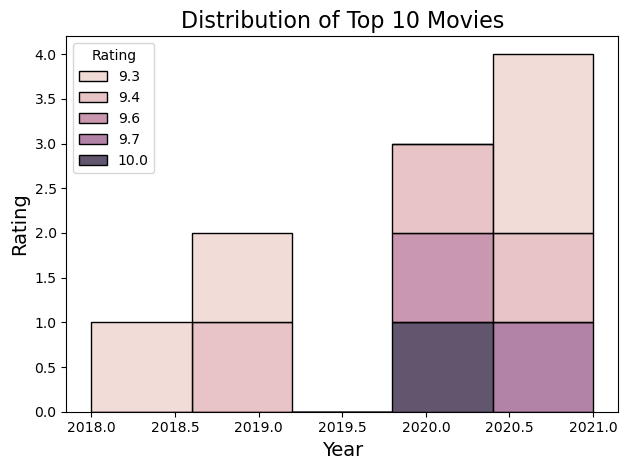

In [58]:
sns.histplot(data=top_movie, x="Year", hue="Rating", multiple="stack")
plt.title('Distribution of Top 10 Movies', fontsize=16)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Rating', fontsize=14)
plt.tight_layout()
plt.show()

In [3]:
import pandas as pd
movie_data = pd.DataFrame({
    'Genre': ['Action', 'Comedy', 'Drama', 'Comedy', 'Action', 'Drama', 'Drama', 'Horror']
})

genre_counts = movie_data['Genre'].value_counts().reset_index()
genre_counts.columns = ['Genre', 'Count']
top_n_genres = genre_counts.head(5)
top_n_genres

,Genre,Count
0,Drama,3
1,Action,2
2,Comedy,2
3,Horror,1


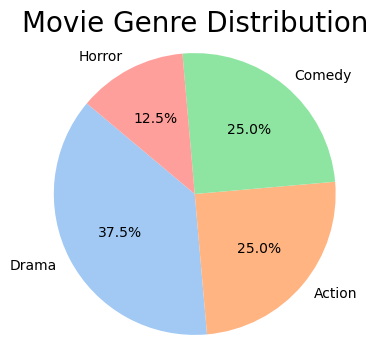

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(4,4))
plt.pie(top_n_genres['Count'], labels=top_n_genres['Genre'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Movie Genre Distribution', fontsize=20)
plt.axis('equal')
plt.show()          

In [11]:
import pandas as pd
movie_data = pd.read_csv('IMDB Movies India.csv.zip', encoding='latin1')
movie_data
director_avg_rating = movie_data.groupby('Director')['Rating'].mean().reset_index()
director_avg_rating = director_avg_rating.sort_values(by='Rating', ascending=False)
top_directors = director_avg_rating.head(10)
top_directors

,Director,Rating
4495,Saif Ali Sayeed,10.0
5154,Sriram Raja,9.7
1017,Bobby Kumar,9.6
647,Arvind Pratap,9.4
675,Ashish Dubey,9.4
5232,Suhrud Godbole,9.4
3046,Munni Pankaj,9.4
5650,Venkatesh Bk,9.3
5819,Vishwa Bhanu,9.3
3767,Raghav Jairath,9.3


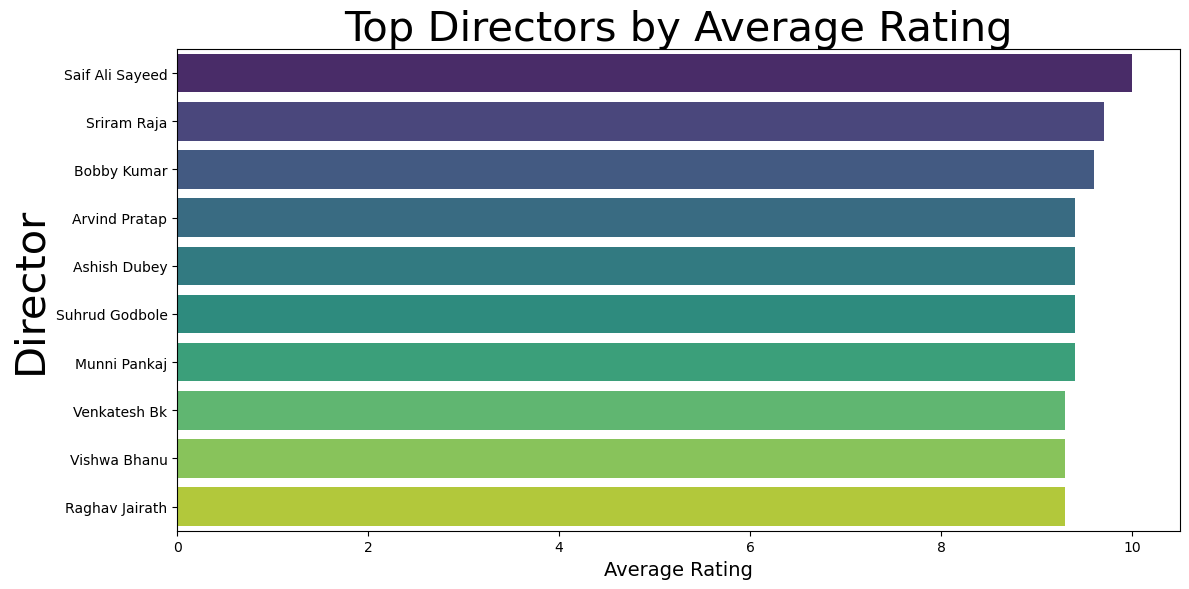

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns  
plt.figure(figsize=(12,6))
sns.barplot(data=top_directors, x='Rating', y='Director', hue='Director', dodge=False, palette='viridis', legend=False)
plt.title('Top Directors by Average Rating', fontsize=30)
plt.xlabel('Average Rating', fontsize=14)
plt.ylabel('Director', fontsize=30)
plt.tight_layout()

plt.show()


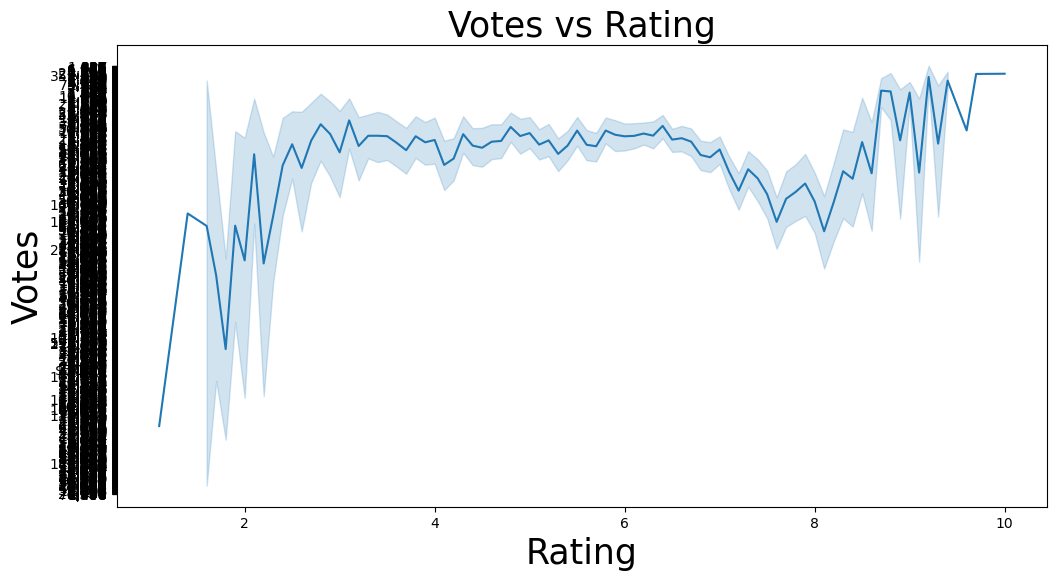

In [29]:
plt.figure(figsize=(12,6))
sns.lineplot(data=movie_data, x='Rating', y='Votes')
plt.title('Votes vs Rating', fontsize=25)
plt.xlabel('Rating', fontsize=25)
plt.ylabel('Votes', fontsize=25)
plt.show()

In [31]:
actor_counts = movie_data['Actor 1'].value_counts().reset_index()
actor_counts.columns = ['Actor', 'MovieCount']
top_n_actors = actor_counts.head(10)
top_n_actors

,Actor,MovieCount
0,Ashok Kumar,158
1,Dharmendra,140
2,Jeetendra,140
3,Mithun Chakraborty,133
4,Amitabh Bachchan,129
5,Rajesh Khanna,122
6,Dev Anand,93
7,Shashi Kapoor,91
8,Akshay Kumar,88
9,Sanjeev Kumar,83


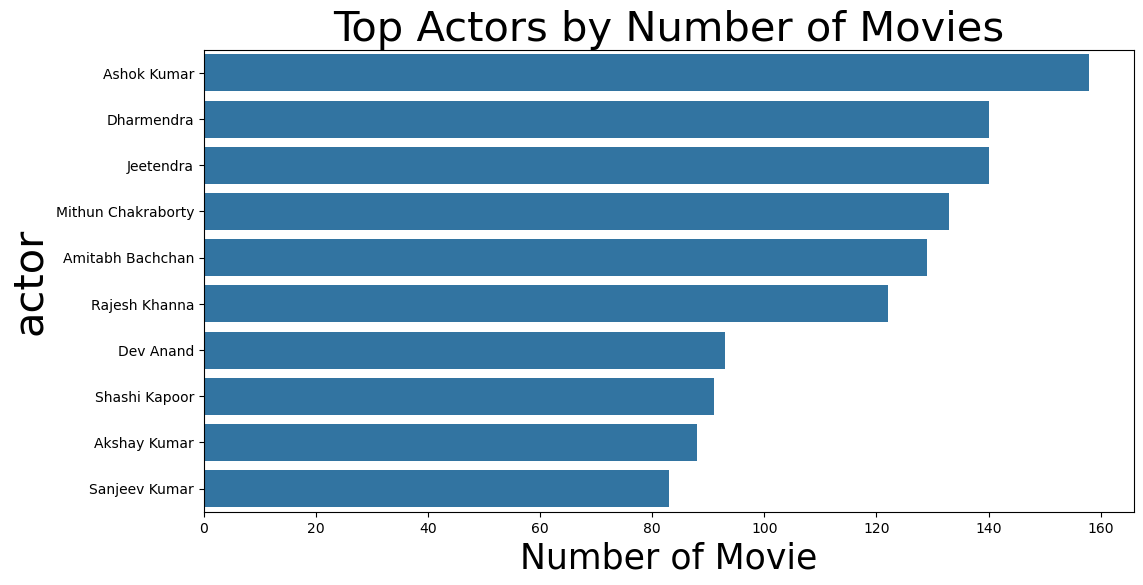

In [33]:
plt.figure(figsize=(12, 6))
sns.barplot(data=top_n_actors, x='MovieCount', y='Actor', orient='h')
plt.title('Top Actors by Number of Movies', fontsize=30)
plt.xlabel('Number of Movie', fontsize=25)
plt.ylabel('actor', fontsize=30)
plt.show()

In [37]:
yearly_movie_counts = movie_data['Year'].value_counts().reset_index()
yearly_movie_counts.columns = ['Year', 'MovieCount']
yearly_movie_counts = yearly_movie_counts.sort_values(by='Year')
yearly_movie_counts

,Year,MovieCount
98,(1913),1
100,(1914),1
95,(1915),1
97,(1917),1
96,(1922),1
...,...,...
2,(2018),381
0,(2019),410
5,(2020),320
1,(2021),392


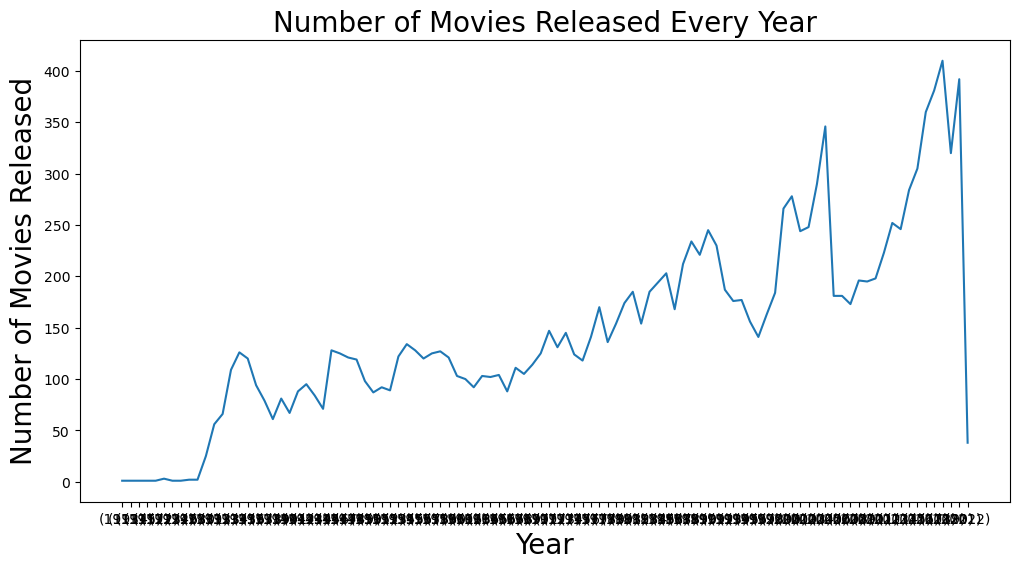

In [41]:
plt.figure(figsize=(12,6))
sns.lineplot(data=yearly_movie_counts, x='Year', y='MovieCount')
plt.title('Number of Movies Released Every Year', fontsize=20)
plt.xlabel('Year', fontsize=20)
plt.ylabel('Number of Movies Released', fontsize=20)
plt.show()

In [43]:
movie_data['Genre'] = movie_data['Genre'].str.split(',')
genre_df = movie_data.explode('Genre')
genre_df

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,Drama,NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
2,#Homecoming,(2021),90 min,Musical,NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,Comedy,4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
...,...,...,...,...,...,...,...,...,...,...
15505,Zulmi,(1999),129 min,Drama,4.5,655,Kuku Kohli,Akshay Kumar,Twinkle Khanna,Aruna Irani
15506,Zulmi Raj,(2005),NaN,Action,NaN,NaN,Kiran Thej,Sangeeta Tiwari,NaN,NaN
15507,Zulmi Shikari,(1988),NaN,Action,NaN,NaN,NaN,NaN,NaN,NaN
15508,Zulm-O-Sitam,(1998),130 min,Action,6.2,20,K.C. Bokadia,Dharmendra,Jaya Prada,Arjun Sarja


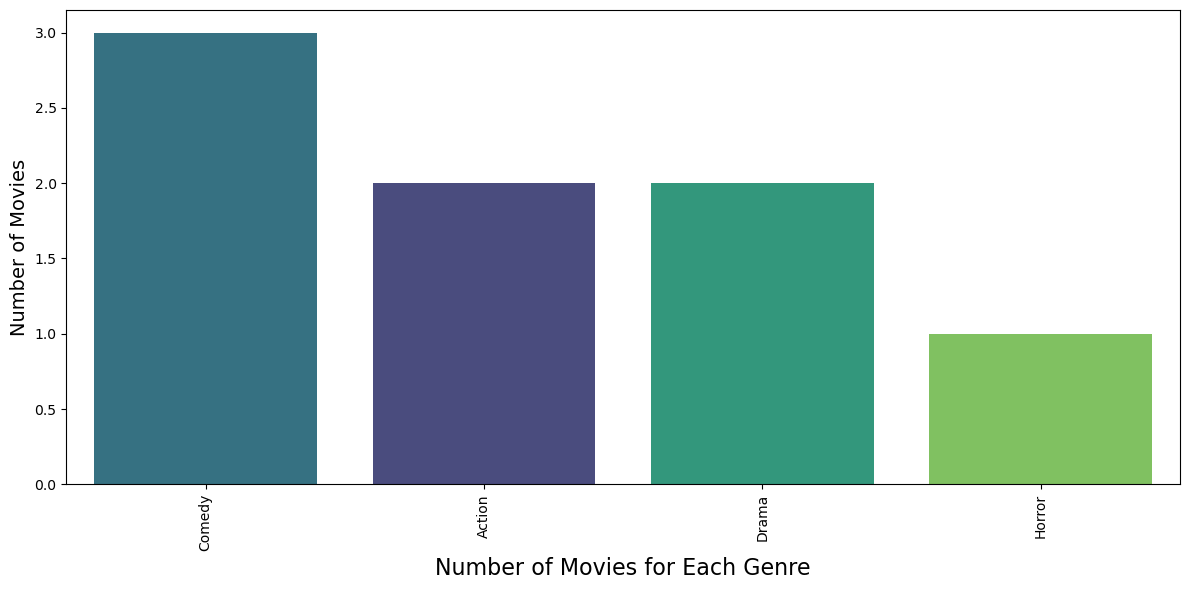

In [17]:
import pandas as pd
data = {'Genre': ['Action', 'Comedy', 'Action', 'Drama', 'Comedy', 'Horror', 'Drama', 'Comedy']}
genre_df = pd.DataFrame(data)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=genre_df, x='Genre', hue='Genre', order=genre_df['Genre'].value_counts().index, palette='viridis',legend=False)
plt.xlabel('Number of Movies for Each Genre', fontsize=16)
plt.ylabel('Number of Movies',fontsize=14)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()



In [52]:
print(genre_df.columns)

if 'Rating' in genre_df.columns and 'Genre' in genre_df.columns:
    average_rating_by_genre = genre_df.groupby('Genre')['Rating'].mean().reset_index()
    average_rating_by_genre = average_rating_by_genre.sort_values(by='Rating', ascending=False)
    print(average_rating_by_genre)
else:
    print("Columns 'Rating' or 'Genre' not found!")


Index(['Genre'], dtype='object')
Columns 'Rating' or 'Genre' not found!


['.anaconda', '.conda', '.condarc', '.continuum', '.ipynb_checkpoints', '.ipython', '.jupyter', '.matplotlib', '3D Objects', 'anaconda3', 'anaconda_projects', 'AppData', 'Application Data', 'bank-loan.csv', 'Book1.xlsx', 'Book2.xlsx', 'Contacts', 'Cookies', 'Documents', 'Downloads', 'Favorites', 'IMDb Movies India.csv.zip', 'IntelGraphicsProfiles', 'Links', 'Local Settings', 'MicrosoftEdgeBackups', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TM.blf', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{2ad838bc-efea-11ee-a54d-000d3a94eaa1}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Recent', 'Saved Games', 'Searches', 'SendTo', 'Start Menu', 'student-dataset.csv', 'submission.csv', 'Templates', 'titanic.zip', 'Tracing', 'Untitled.ipynb', 'Untitled1.ipynb', 'Untitled11.ipynb', 'Videos']
['IMDb Movie

<function matplotlib.pyplot.show(close=None, block=None)>

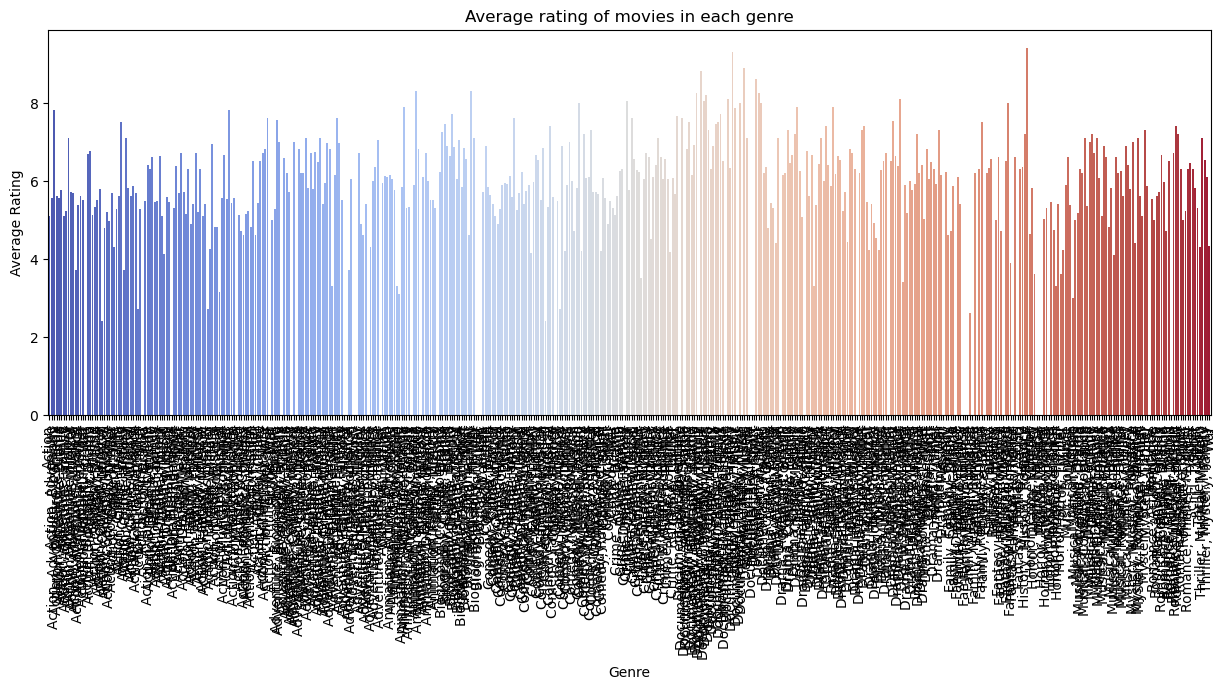

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns  
import os
print(os.listdir())
file_path = r"E:\Path\To\Your\File\IDMB Movies India.csv.zip"

import zipfile
with zipfile.ZipFile("IMDB Movies India.csv.zip", 'r') as z:
    print(z.namelist())
import pandas as pd
df = pd.read_csv("IMDB Movies India.csv.zip", compression='zip', encoding='latin1')
df.head()
print(df.columns)
df.columns
average_rating_by_genre = df.groupby('Genre')['Rating'].mean().reset_index()

plt.figure(figsize=(15,5))
sns.barplot(data=average_rating_by_genre, y='Rating', x='Genre', hue='Genre', palette='coolwarm')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.title('Average rating of movies in each genre')
plt.xticks(rotation=90)
plt.show



In [33]:
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()

trans_data = df.drop(['Name'],axis=1)

trans_data['Director'] = labelencoder.fit_transform(df['Director'])

trans_data['Actor 1'] = labelencoder.fit_transform(df['Actor 1'])
trans_data['Actor 2'] = labelencoder.fit_transform(df['Actor 2'])
trans_data['Actor 3'] = labelencoder.fit_transform(df['Actor 3'])

trans_data['Genre'] = labelencoder.fit_transform(df['Genre'])
trans_data.head()

,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,NaN,NaN,299,NaN,NaN,1926,2250,800,3108
1,(2019),109 min,299,7.0,8,1548,3280,4790,527
2,(2021),90 min,351,NaN,NaN,5123,3713,2866,3450
3,(2019),110 min,228,4.4,35,3319,2917,1504,4020
4,(2010),105 min,299,NaN,NaN,385,3112,3462,405


In [37]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

numeric_columns = trans_data.select_dtypes(include=['float64', 'int64'])

sc_data = scaler.fit_transform(numeric_columns)
sc_df = pd.DataFrame(sc_data,columns=numeric_columns.columns)
sc_df.head()


,Rating
0,NaN
1,0.662921
2,NaN
3,0.370787
4,NaN


In [39]:
corr_df = trans_data.corr(numeric_only=True)
corr_df['Rating'].sort_values(ascending=False)

Rating      1.000000
Genre       0.125416
Actor 3     0.060049
Actor 2     0.059205
Actor 1     0.039774
Director   -0.008283
Name: Rating, dtype: float64

<Axes: >

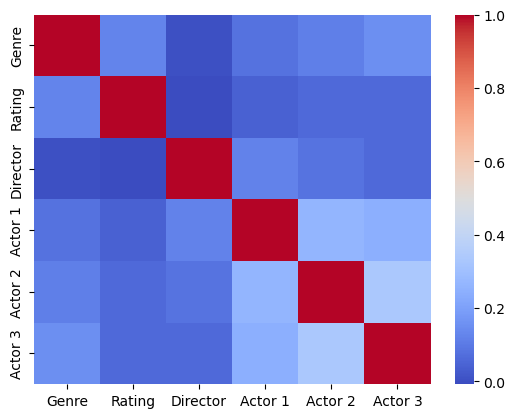

In [43]:
sns.heatmap(corr_df,annot=False,cmap="coolwarm")

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [47]:
X = trans_data.drop(['Rating'],axis=1)

In [49]:
y = trans_data['Rating']

In [59]:
trans_data = trans_data.dropna()

X = trans_data.drop(columns=['Rating'])
y = trans_data['Rating']

print(X.dtypes)

X = pd.get_dummies(X, drop_first=True)

# 5. Train/test split
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 6. Train model
model = LinearRegression()
model.fit(X_train, y_train)


Year        object
Duration    object
Genre        int32
Votes       object
Director     int32
Actor 1      int32
Actor 2      int32
Actor 3      int32
dtype: object


LinearRegression()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
import numpy as np

iris = load_iris()
X = iris.data
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

X_test = np.array(X_test)


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200)  
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(y_pred)


[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]


In [19]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print('R2 score: ',r2_score(y_test,y_pred))
print('Mean squared error: ',mean_squared_error(y_test,y_pred))
print('Mean absolute error: ',mean_absolute_error(y_test,y_pred))

R2 score:  1.0
Mean squared error:  0.0
Mean absolute error:  0.0


In [21]:
print(y_test)

[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
